In [3]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated
from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage,SystemMessage,HumanMessage

In [4]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
model=init_chat_model(
    "openai/gpt-oss-120b",
    model_provider="groq",
    temperature=0.4
)

In [7]:
def chat_message(state:ChatState):
    response=model.invoke(state["messages"])
    return {"messages":[response]}

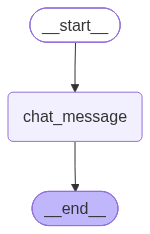

In [8]:
graph=StateGraph(ChatState)

graph.add_node("chat_message",chat_message)

graph.add_edge(START,"chat_message")
graph.add_edge("chat_message",END)

workflow=graph.compile()
workflow

In [9]:
initial_state={
    "messages":[HumanMessage(content="what is object oriented programming")]
}
final_state=workflow.invoke(initial_state)

In [10]:
final_state

{'messages': [HumanMessage(content='what is object oriented programming', additional_kwargs={}, response_metadata={}, id='3285c42c-ae70-4b31-b84a-b2955c7e2715'),
  AIMessage(content='**Object‑Oriented Programming (OOP)** is a programming paradigm that organizes software around *objects* rather than just functions or logic. An object is a self‑contained “thing” that bundles both **data** (its state) and **behaviors** (the operations that can be performed on that data).  \n\nBelow is a concise overview of the core ideas, why they matter, and how they are used in practice.\n\n---\n\n## 1. Core Concepts\n\n| Concept | What it means | Typical syntax (e.g., Python / Java) |\n|---------|---------------|--------------------------------------|\n| **Class** | A blueprint for creating objects. It defines the attributes (variables) and methods (functions) that the objects will have. | `class Dog:` (Python) <br>`public class Dog { … }` (Java) |\n| **Object / Instance** | A concrete realization of a

In [11]:
final_state["messages"][-1].content

'**Object‑Oriented Programming (OOP)** is a programming paradigm that organizes software around *objects* rather than just functions or logic. An object is a self‑contained “thing” that bundles both **data** (its state) and **behaviors** (the operations that can be performed on that data).  \n\nBelow is a concise overview of the core ideas, why they matter, and how they are used in practice.\n\n---\n\n## 1. Core Concepts\n\n| Concept | What it means | Typical syntax (e.g., Python / Java) |\n|---------|---------------|--------------------------------------|\n| **Class** | A blueprint for creating objects. It defines the attributes (variables) and methods (functions) that the objects will have. | `class Dog:` (Python) <br>`public class Dog { … }` (Java) |\n| **Object / Instance** | A concrete realization of a class. Each object has its own copy of the class’s attributes. | `my_dog = Dog()` (Python) <br>`Dog myDog = new Dog();` (Java) |\n| **Encapsulation** | Hides the internal state of a

In [12]:
while True:
    query=input("Type here:")
    if query.strip().lower() in ['exit','quit','bye']:
        print("User stopped querying")
        break
    else:
        initial_state={"messages":[query]}
        final_state=workflow.invoke(initial_state)
        print(f"\n{final_state["messages"][-1].content}\n")
        print("*" * 50)



Hello! How can I help you today?

**************************************************

Nice to meet you, Aswin! How can I assist you today?

**************************************************

You’re chatting with **ChatGPT**, OpenAI’s conversational AI built on the GPT‑4 architecture.

**************************************************

GPT‑4 was developed by **OpenAI**, the artificial‑intelligence research organization that also created the earlier GPT‑3 model and the ChatGPT products built on these models. OpenAI’s team of researchers, engineers, and scientists designed, trained, and released GPT‑4 as the next generation of its large‑scale language models.

**************************************************
User stopped querying


## Now we need to add Persistence

In [13]:
from langgraph.checkpoint.memory import MemorySaver

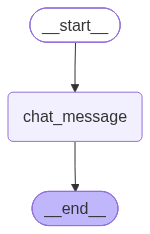

In [14]:
checkpoint=MemorySaver()
graph=StateGraph(ChatState)

graph.add_node("chat_message",chat_message)

graph.add_edge(START,"chat_message")
graph.add_edge("chat_message",END)

workflow=graph.compile(checkpointer=checkpoint)
workflow

In [15]:
thread_id="1"
while True:
    query=input("Type here:")
    if query.strip().lower() in ['exit','quit','bye']:
        print("User stopped querying")
        break
    config={"configurable":{"thread_id":thread_id}}
    initial_state={"messages":[HumanMessage(content=query)]}
    final_state=workflow.invoke(initial_state,config=config)
    print(f"\n{final_state["messages"][-1].content}\n")
    print("*" * 50)



Nice to meet you, Aswin! How can I assist you today?

**************************************************

**Python** is a high‑level, interpreted programming language that emphasizes readability and simplicity. It was created by Guido van Rossum and first released in 1991. Here are the key points that define Python:

| Aspect | Details |
|--------|---------|
| **Paradigms** | Supports multiple programming styles: procedural, object‑oriented, functional, and imperative. |
| **Syntax** | Clean, English‑like syntax with indentation used to define code blocks (instead of braces or keywords). |
| **Interpreted** | Code is executed by the Python interpreter line‑by‑line, so you don’t need a separate compilation step. |
| **Dynamic typing** | Variable types are determined at runtime; you can assign any type of value to a variable without declaring its type. |
| **Standard library** | Comes with a “batteries‑included” standard library that provides modules for file I/O, networking, web servic

In [16]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='my name is Aswin', additional_kwargs={}, response_metadata={}, id='42159149-77a1-4931-9adf-69c8c5719b68'), AIMessage(content='Nice to meet you, Aswin! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "my name is Aswin". Likely they want the assistant to acknowledge or respond. There\'s no request for disallowed content. So respond politely, maybe ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 76, 'total_tokens': 141, 'completion_time': 0.134579428, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.003092034, 'prompt_tokens_details': None, 'queue_time': 0.212836593, 'total_time': 0.137671462}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a655021f7d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e77a-d036-7483-84e8-d212ee27306c-0', tool